In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.pipeline import make_pipeline,Pipeline
from sklearn.compose import make_column_transformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,StandardScaler,MinMaxScaler

import warnings
warnings.filterwarnings('ignore')

In [3]:
path = 'https://frenzy86.s3.eu-west-2.amazonaws.com/fav/tips.csv'

df = pd.read_csv(path).drop_duplicates().reset_index(drop=True)
df


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
238,29.03,5.92,Male,No,Sat,Dinner,3
239,27.18,2.00,Female,Yes,Sat,Dinner,2
240,22.67,2.00,Male,Yes,Sat,Dinner,2
241,17.82,1.75,Male,No,Sat,Dinner,2


In [ ]:
## features #total_bill','day', 'time'
## drop duplicates
## OHE yes
## Normalizz == yes
## model linear regression
## R2 cross 0.43

In [6]:
#STEP 0 FILTERING
#remove features not useful
df_clean = df[['total_bill','day', 'time','tip']]
#df_clean = df.copy()

In [7]:
# STEP 1 - TRAIN TEST SPLITTING
#Feature matrix and target vector

TARGET = 'tip'
X = df_clean.drop([TARGET], axis=1) # matrice Features
y = df_clean[TARGET]                #Target

## Simple Imputer
https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html

Il SimpleImputer è utilizzato per gestire i valori mancanti (NaN) all'interno dei dati. Nella tua pipeline, viene utilizzato per imputare i valori mancanti nelle feature numeriche, sostituendoli con la mediana dei valori presenti in quella colonna.

Ad esempio, supponiamo di avere una feature numerica come l'età di una persona e alcuni valori sono mancanti. Utilizzando SimpleImputer(strategy='median'), verranno sostituiti i valori mancanti con la mediana dell'età di tutte le altre persone.

Questo aiuta a mantenere la completezza dei dati durante l'analisi, poiché molti algoritmi di machine learning non possono gestire direttamente i valori mancanti.

- Se impostato su "mean", sostituisce i valori mancanti utilizzando la media lungo ciascuna colonna. Può essere utilizzato solo con dati numerici.

- Se impostato su "median", sostituisce i valori mancanti utilizzando la mediana lungo ciascuna colonna. Può essere utilizzato solo con dati numerici.

- Se impostato su "most_frequent", sostituisce i valori mancanti utilizzando il valore più frequente lungo ciascuna colonna. Può essere utilizzato con dati di tipo stringa o numerici. Se ci sono più valori più frequenti, viene restituito solo il più piccolo.

- Se impostato su "constant", sostituisce i valori mancanti con il valore specificato in fill_value. Può essere utilizzato con dati di tipo stringa o numerici.



In [8]:
X.columns

Index(['total_bill', 'day', 'time'], dtype='object')

In [11]:
## dividiamo automaticamente le features numeriche da quelle categoriche

numerical_features = [x for x, dtype in zip(X.columns, X.dtypes) if dtype.kind in ['i','f'] ]
categorical_features = [x for x, dtype in zip(X.columns, X.dtypes) if dtype.kind not in ['i','f']]

print('Numerical : ' + str(numerical_features))
print('Categorical : ' + str(categorical_features))

Numerical : ['total_bill']
Categorical : ['day', 'time']


In [12]:
def remove_outliers(X, y, columns, factor=1.5):
    for col in columns:
        Q1 = X[col].quantile(0.25)
        Q3 = X[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - factor * IQR
        upper_bound = Q3 + factor * IQR
        outlier_mask = (X[col] >= lower_bound) & (X[col] <= upper_bound)
        X = X[outlier_mask]
        y = y[outlier_mask]
    return X, y

## numerical_features  ['CRIM', 'NOX', 'RM', 'DIS', 'PTRATIO', 'LSTAT']
X, y = remove_outliers(X, y, numerical_features)

In [13]:
## Parte di processingdata: Cleaning, fill Nan + OHE
Preprocessor = make_column_transformer(
                                        (make_pipeline(
                                        SimpleImputer(strategy = 'median'),), numerical_features),

                                        (make_pipeline(
                                        #FunctionTransformer(lambda x: np.where(x == 'n.d.', np.nan, x)),
                                        SimpleImputer(strategy = 'constant', fill_value = 'missing'),
                                        OneHotEncoder(categories = 'auto', handle_unknown = 'ignore',drop='first')), categorical_features)
                                        )
Preprocessor

ColumnTransformer(transformers=[('pipeline-1',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['total_bill']),
                                ('pipeline-2',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(fill_value='missing',
                                                                strategy='constant')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'))]),
                                 ['day', 'time'])])

## RFE
RFE is popular because it is easy to configure and use and because it is effective at selecting those features (columns) in a training dataset that are more or most relevant in predicting the target variable.

There are two important configuration options when using RFE: the choice in the number of features to select and the choice of the algorithm used to help choose features. Both of these hyperparameters can be explored, although the performance of the method is not strongly dependent on these hyperparameters being configured well.

In [15]:
from sklearn.feature_selection import SelectKBest, f_regression,RFE
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor

scaler = MinMaxScaler()
regressor = LinearRegression()
# regressor = GradientBoostingRegressor(
#                                         learning_rate=0.1,
#                                         max_depth=3,
#                                         min_samples_split=10,
#                                         n_estimators=100
#                                         )

f_selection = RFE(estimator=regressor, n_features_to_select=5, step=1)
#f_selection = SelectKBest(score_func=f_regression, k=10)  # k=numero features da selezionare

In [16]:
model_pipe = Pipeline([
                       ('Preprocessing features', Preprocessor),
                       ('Scaling data', scaler),
                       #('Feature selection', f_selection),
                       ('Regressor', regressor),
                      ])
model_pipe

Pipeline(steps=[('Preprocessing features',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['total_bill']),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['day', 'time'])])),
                ('Scaling data', MinMaxScaler()),
                ('Regressor', LinearRegression())])

In [17]:
from sklearn.metrics import mean_squared_error, r2_score,root_mean_squared_error,mean_absolute_percentage_error
from sklearn.model_selection import KFold, cross_val_predict

# Configurazione cross-validation e predizioni
cv = KFold(n_splits=5, shuffle=True, random_state=667) #KFold per le regress
y_pred = cross_val_predict(model_pipe, X, y, cv=cv)

mse = mean_squared_error(y, y_pred)
rmse = root_mean_squared_error(y, y_pred)
mape = mean_absolute_percentage_error(y, y_pred)
r2 = r2_score(y, y_pred)

# Stampa risultati
print("Metriche di valutazione:")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.2f}%")
print(f"R²: {r2:.4f}")

Metriche di valutazione:
MSE: 0.8636
RMSE: 0.9293
MAPE: 0.27%
R²: 0.3897


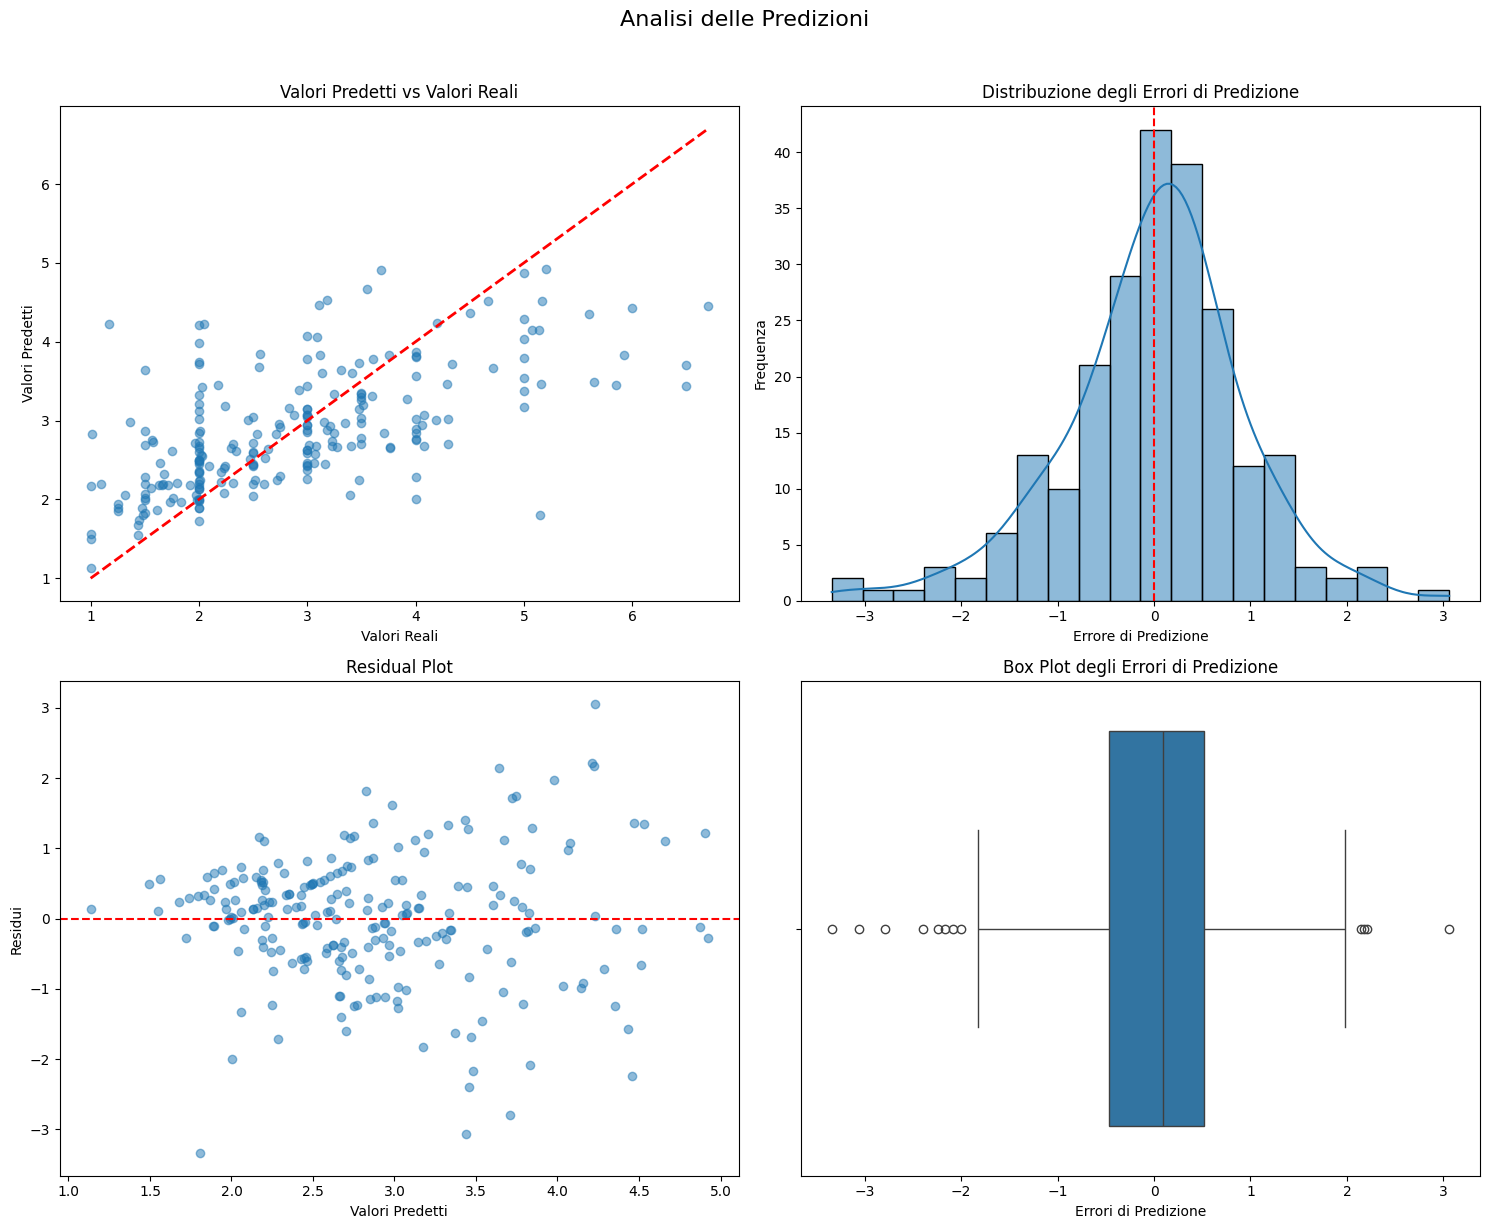


Statistiche degli errori:
Media degli errori: -0.0019
Deviazione standard degli errori: 0.9313
Errore minimo: -3.3423
Errore massimo: 3.0596


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Analisi delle Predizioni', fontsize=16, y=1.02)

# 1. Scatter plot Predicted vs Actual
axes[0,0].scatter(y, y_pred, alpha=0.5)
axes[0,0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[0,0].set_xlabel('Valori Reali')
axes[0,0].set_ylabel('Valori Predetti')
axes[0,0].set_title('Valori Predetti vs Valori Reali')

# 2. Distribuzione degli errori
errors = y_pred - y
sns.histplot(errors, kde=True, ax=axes[0,1])
axes[0,1].axvline(x=0, color='r', linestyle='--')
axes[0,1].set_xlabel('Errore di Predizione')
axes[0,1].set_ylabel('Frequenza')
axes[0,1].set_title('Distribuzione degli Errori di Predizione')

# 3. Residual plot
axes[1,0].scatter(y_pred, errors, alpha=0.5)
axes[1,0].axhline(y=0, color='r', linestyle='--')
axes[1,0].set_xlabel('Valori Predetti')
axes[1,0].set_ylabel('Residui')
axes[1,0].set_title('Residual Plot')

# 4. Box plot degli errori
sns.boxplot(x=errors, ax=axes[1,1])
axes[1,1].set_xlabel('Errori di Predizione')
axes[1,1].set_title('Box Plot degli Errori di Predizione')

plt.tight_layout()
plt.show()

print("\nStatistiche degli errori:")
print(f"Media degli errori: {errors.mean():.4f}")
print(f"Deviazione standard degli errori: {errors.std():.4f}")
print(f"Errore minimo: {errors.min():.4f}")
print(f"Errore massimo: {errors.max():.4f}")

## Fit the model with entire dataset!!!

<img src='https://frenzy86.s3.eu-west-2.amazonaws.com/python/cross.png' width=600>


In [19]:
model_pipe.fit(X, y)

Pipeline(steps=[('Preprocessing features',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['total_bill']),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['day', 'time'])])),
                ('Scaling data', MinMaxScaler()),
                ('Regressor', LinearRegression())])

In [21]:
import joblib

joblib.dump(model_pipe,'tip_pipe.pkl')

['tip_pipe.pkl']

## Load Model

In [22]:
import joblib

model_pipe_load = joblib.load('tip_pipe.pkl')
print('Model loaded successfully')

Model loaded successfully


## Inference of single observation

In [23]:
X.columns

Index(['total_bill', 'day', 'time'], dtype='object')

In [24]:
X.iloc[0]

,0
total_bill,16.99
day,Sun
time,Dinner


In [28]:
TOTAL_BILL = 35
DAY = 'Sun'
TIME = 'Dinner'

data = {
        "total_bill": [TOTAL_BILL],
        "day": [DAY],
        "time": [TIME],
        }

input_df = pd.DataFrame(data)
res = model_pipe_load.predict(input_df).astype(float)[0].round(2)
print(res)

4.82


## Gradio

In [30]:
import gradio as gr
import joblib
import pandas as pd

model_pipe_load = joblib.load('tip_pipe.pkl')
print('Model loaded successfully')

def predict_price(TOTAL_BILL, DAY, TIME):
    data = {
            "total_bill": [TOTAL_BILL],
            "day": [DAY],
            "time": [TIME],
            }

    input_df = pd.DataFrame(data)
    res = model_pipe_load.predict(input_df).astype(int)[0]
    return f"Tip predetta: ${res}"

# Crea l'interfaccia Gradio
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🏠 Predizione Prezzi Case Boston")
    gr.Markdown("Inserisci le caratteristiche della proprietà per ottenere una stima del prezzo")

    with gr.Row():
        with gr.Column():
            totbill_input = gr.Number(
                                    label="TTot Bill",
                                    value=40,
                                    info="Total_Bill"
                                    )
            day_input = gr.Textbox(
                                    label="day",
                                    value='Sun',
                                    info="day"
                                    )
            time_input = gr.Textbox(
                                label="time",
                                value='Dinner',
                                info="time"
                                )

    predict_btn = gr.Button("🔮 Predici Tips", variant="primary")
    output = gr.Textbox(label="Risultato", scale=2)

    predict_btn.click(
                        fn=predict_price,
                        inputs=[totbill_input, day_input, time_input],
                        outputs=output
                        )

    gr.Examples(
        examples=[
                [0.006, 0.538, 6,],
                [0.02731, 0.469, 5, 4.967, 17.8, 9.14],
                [0.06076, 0.458, 7, 6.062, 17.8, 5.64],
                ],
                inputs=[totbill_input, day_input, time_input],
            )

if __name__ == "__main__":
    demo.launch(share=True)

Model loaded successfully
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://73ce493ab4ab8406a6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
